## 이미지의 기하학적 변환


### 이미지의 어파인 변환 (Affine Transformation)
**어파인 변환**
- 영상을 평행 이동시키거나 회전, 크기 변환 등을 할 수 있음
- 변환 전 이미지와 변환 후 이미지의 세 점의 이동 관계에 의해 결정
- **Affine Transformation Matrix**: 어파인 변환은 두 이미지의 관계를 정의한 2×3 매트릭스로 설명할 수 있음
- 매트릭스는 numpy.float32 실수형 자료형을 사용
  - **uint8**: $2^{8}$개의 0에서 255까지 부호없는 8비트 정수표현
    - 그레이스케일 또는 RGB채널 컬러 이미지를 표현할 때 사용  
  - **float32**: $2^{32}$bits:  부호(1비트)+정수(8비트)+소수(23비트)


**이동 변환**

``` cv2.warpAffine(srcImage, matrix,(width, height))```

```이동변환 넘파이 매트릭스
   [[1, 0, translateX],
   [0, 1, translateY]]

In [1]:
#구글 드라이브 마운트 하기
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


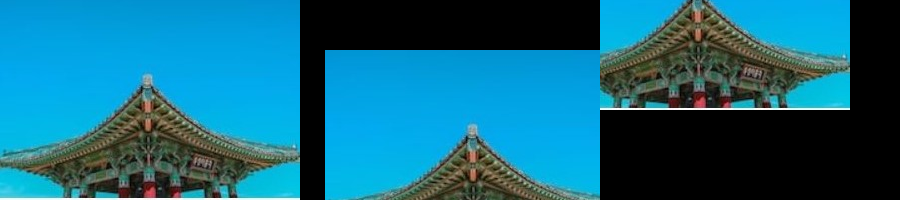

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

# 이동변환 넘파이 매트릭스
# [[1, 0, translateX],
# [0, 1, translateY]]

M = np.float32([[1, 0, 25],
                [0, 1, 50]])

shiftedImage1 = cv2.warpAffine(image, M, (width,height))

M = np.float32([[1, 0, -50],
                [0, 1, -90]])
shiftedImage2 = cv2.warpAffine(image, M, (width,height))

shift_frame = cv2.hconcat([image, shiftedImage1, shiftedImage2])
cv2_imshow(shift_frame)


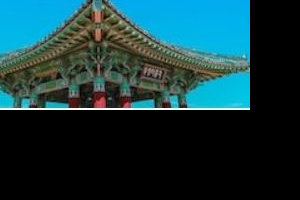

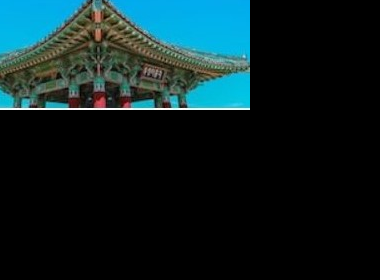

In [3]:
shiftedImage = cv2.warpAffine(image, M, (width, height))
extendedImage = cv2.warpAffine(image, M, (width+80, height+80))

cv2_imshow(shiftedImage)
cv2_imshow(extendedImage)

**크기 변환**
1. 원본 이미지 사이즈 내에서 크기 변환
```cv2.warpAffine(srcImage, matrix,(width, height)```

크기 변환의 Affine Matrix
```
[[scaleX, 0, 0],
[0,  scaleY, 0]]

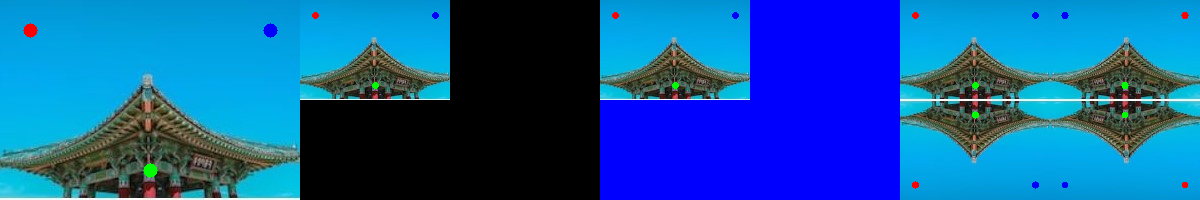

In [4]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

# 이미지에 점 세 개 표시
cv2.circle(image, (30,30), 7, (0,0,255), -1)
cv2.circle(image, (width//2, height-30 ), 7, (0,255,0), -1)
cv2.circle(image, (width-30,30), 7, (255,0,0), -1)

# 이미지 축소
M = np.float32([[0.5, 0, 0],
               [0, 0.5, 0]])
scaledimage1 = cv2.warpAffine(image, M, (width, height))

# cv2.INTER_LINEAR -> 이미지 확대 축소
# 이미지가 없는 부분을 파랑색으로 보정(cv2.BORDER_CONSTANT)
scaledimage2 = cv2.warpAffine(image, M, (width, height), None, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT, (255,0,0))

# 이미지가 없는 부분 원본을 반사 시켜서 보정(cv2.BORDER_REFLECT)
scaledimage3 = cv2.warpAffine(image, M, (width, height), None, cv2.INTER_LINEAR, cv2.BORDER_REFLECT)

shift_frame = cv2.hconcat([image, scaledimage1, scaledimage2, scaledimage3])
cv2_imshow(shift_frame)


2. resize 함수를 사용한 이미지 크기 변환
```cv2.resize(srcImage, dimension, fx, fy, interpolation)```

Parameters:

- srcImage - 변환할 이미지
- dimension - 튜플형식의 이미지 사이즈 (가로,세로)
- fx - 가로 사이즈의 배수 (2배: 2, 0.5배: 0.5)
- fy - 세로 사이즈의 배수
- interpolation(보간법) - 이미지 크기가 변할 때 픽셀 사이 값을 결정
  - cv2.INTER_AREA
  - cv2.INTER_CUBIC
  - cv2.INTER_LINEAR

(200, 300, 3)


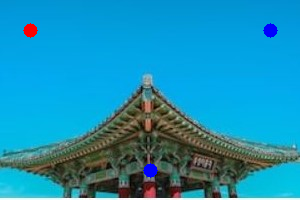

(100, 300, 3)


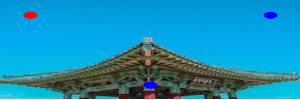

(100, 150, 3)


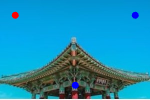

(300, 450, 3)


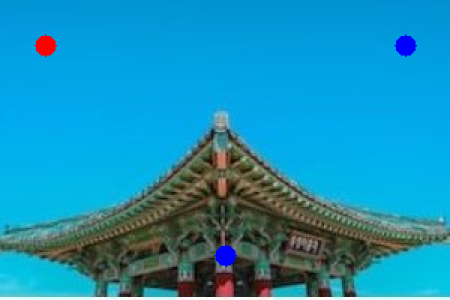

(100, 150, 3)


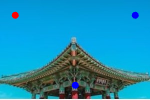

In [5]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

cv2.circle(image, (30, 30), 7, (0, 0, 255), -1)
cv2.circle(image, (width//2, height-30), 7, (255, 0, 0), -1)
cv2.circle(image, (width-30, 30), 7, (255, 0, 0), -1)

print(image.shape)
cv2_imshow(image)

# 확대/축소할 가로, 세로 크기 지정
dimension = (300, 100)
resizedimage = cv2.resize(image, dimension, interpolation = cv2.INTER_AREA)

print(resizedimage.shape)
cv2_imshow(resizedimage)

# 비율을 맞춰 축소
scale = 0.5
dimension = (int(width * scale), int(height * scale))
resizedimage = cv2.resize(image, dimension, interpolation = cv2.INTER_AREA)

print(resizedimage.shape)
cv2_imshow(resizedimage)

# 비율을 맞춰 확대하기
scale = 1.5
dimension = (int(width*scale),int(height*scale))
resizedimage = cv2.resize(image, dimension, interpolation = cv2.INTER_AREA)

print(resizedimage.shape)
cv2_imshow(resizedimage)

# 비율을 맞춰 크기변환하기
resizedImage = cv2.resize(image, None, fx=0.5, fy=0.5)
print(resizedImage.shape)
cv2_imshow(resizedImage)

**회전 변환**
- 어파인 매트릭스를 사용한 회전

```cv2.warpAffine(srcImage, matrix, (width, height))```

회전 변환의 Affine Matrix

```
[[𝑐𝑜𝑠𝜃, 𝑠𝑖𝑛𝜃, 0],
[-𝑠𝑖𝑛𝜃, 𝑐𝑜𝑠𝜃, 0]]

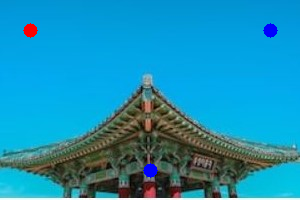

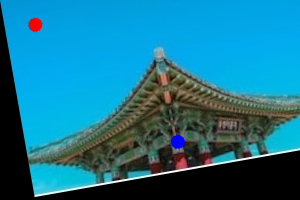

1. (0,0) rotation 
 [[ 0.9848077   0.17364818  0.        ]
 [-0.17364818  0.9848077   0.        ]]


In [6]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

cv2.circle(image, (30, 30), 7, (0, 0, 255), -1)
cv2.circle(image, (width//2, height-30), 7, (255, 0, 0), -1)
cv2.circle(image, (width-30, 30), 7, (255, 0, 0), -1)
cv2_imshow(image)

degree = 10
sin = np.sin(np.deg2rad(degree))
cos = np.cos(np.deg2rad(degree))

M = np.float32([[cos, sin, 0],
                [-sin, cos, 0]])

shiftedImage = cv2.warpAffine(image, M, (width,height))
cv2_imshow(shiftedImage)

print("1. (0,0) rotation \n", M)

- getRotationMatrix2D함수를 사용해 회전하기
```cv2.getRotationMatrix2D(originPoint, angle, scale)```

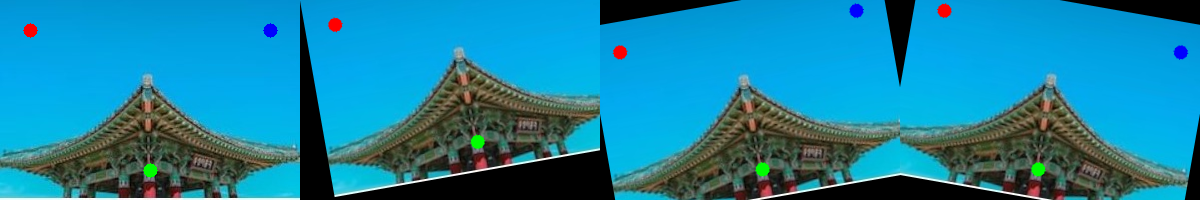

1. (0,0) rotation 
 [[ 0.98480775  0.17364818  0.        ]
 [-0.17364818  0.98480775  0.        ]]
2. (150, 100) rotation 
 [[  0.98480775   0.17364818 -15.08598072]
 [ -0.17364818   0.98480775  27.56645135]]
3. (150, 100) rotation 
 [[  0.98480775  -0.17364818  19.64365481]
 [  0.17364818   0.98480775 -24.52800195]]


In [7]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, channel) = image.shape[:]
center = (width//2, height//2)
topLeft =(0,0)

degree = 10

# 이미지에 점 세 개 표시
cv2.circle(image, (30,30), 7, (0,0,255), -1)
cv2.circle(image, (width//2,height-30), 7, (0,255,0), -1)
cv2.circle(image, (width-30,30), 7, (255,0,0), -1)

# (0, 0)을 기준으로 반시계방향 회전
M_topLeft = cv2.getRotationMatrix2D(topLeft, degree, 1)
topLeftRotated = cv2.warpAffine(image, M_topLeft, (width, height))

# 이미지의 중심을 기준으로 반시계방향 회전
M_center = cv2.getRotationMatrix2D(center, degree, 1)
centerRotated = cv2.warpAffine(image, M_center, (width, height))

# 이미지의 중심을 기준으로 시계방향 회전
M_invCenter = cv2.getRotationMatrix2D(center, -degree, 1)
centerinvRotated = cv2.warpAffine(image, M_invCenter, (width, height))

rotate_frame = cv2.hconcat([image, topLeftRotated,centerRotated,centerinvRotated])
cv2_imshow(rotate_frame)

print("1. (0,0) rotation \n", M_topLeft)
print("2.",center,"rotation \n", M_center)
print("3.",center,"rotation \n", M_invCenter)


**반전 변환(Reflection Transformation)**
- 어파인 매트릭스를 사용한 반전

```cv.warpAffine(srcImage, matrix, (width, height))```

반전 변환의 Affine Matrix

x축 반전변환 넘파이 매트릭스
```
[[1, 0, translateX],
[0, -1, translateY]]
```

y축 반전변환 넘파이 매트릭스
```
[[-1, 0, translateX],
[0, 1, translateY]]
```

원점(origin) 반전변환 넘파이 매트릭스
```
[[-1, 0, translateX],
[0, -1, translateY]]

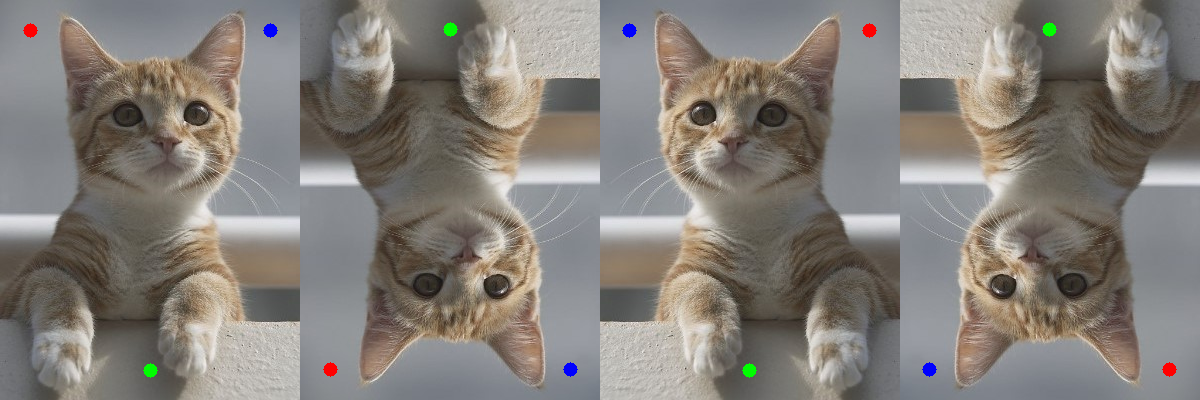

In [8]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/cat_300x400.jpg')
(height, width, channel) = image.shape[:]

# 이미지에 점 세 개 표시
cv2.circle(image, (30,30), 7, (0,0,255), -1)
cv2.circle(image, (width//2,height-30), 7, (0,255,0), -1)
cv2.circle(image, (width-30,30), 7, (255,0,0), -1)

M = np.float32([[1, 0, 0],
                [0, 1, 0]])
notReflected = cv2.warpAffine(image, M, (width, height))

M = np.float32([[1, 0, 0],
               [0, -1, height-1]])
xReflected = cv2.warpAffine(image, M, (width, height))

M = np.float32([[-1, 0, width-1],
                [0, 1, 0]])
yReflected = cv2.warpAffine(image, M, (width, height))

M = np.float32([[-1, 0, width-1],
                [0, -1, height-1]])
xyReflected = cv2.warpAffine(image, M, (width, height))

reflect_frame = cv2.hconcat([notReflected, xReflected, yReflected, xyReflected])
cv2_imshow(reflect_frame)

- filp 함수를 이용한 반전
```cv2.flip(image, reflection)```

Parameter:

- image: 반전변환 할 이미지
- reflection
  - 0: x축으로 뒤집기 (vertical flipping)
  - 1: y축으로 뒤집기 (horizontal flipping)
  - -1: x축과 y축으로 뒤집기 (vertical and horizontal flipping)

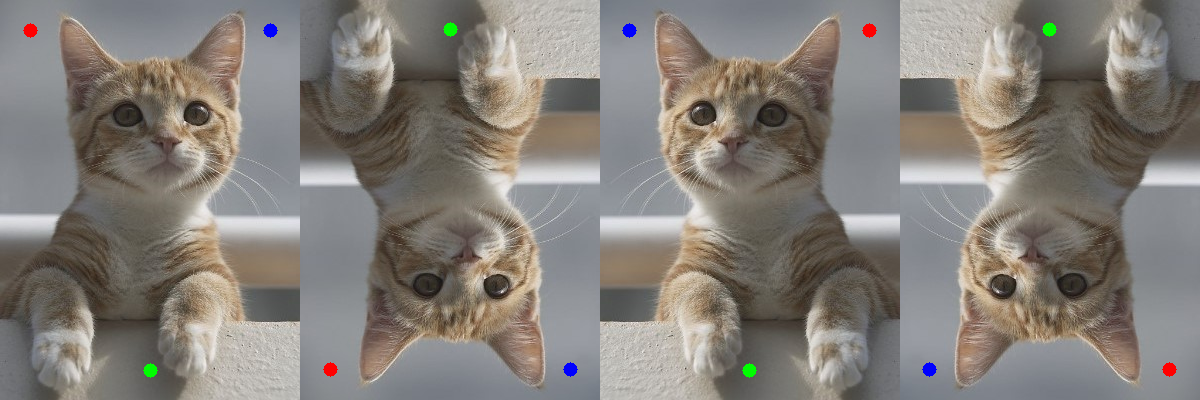

In [9]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/cat_300x400.jpg')
(height, width, channel) = image.shape[:]

# 이미지에 점 세 개 표시
cv2.circle(image, (30,30), 7, (0,0,255), -1)
cv2.circle(image, (width//2,height-30), 7, (0,255,0), -1)
cv2.circle(image, (width-30,30), 7, (255,0,0), -1)

flipVertical = cv2.flip(image, 0)
flipHorizontal = cv2.flip(image, 1)
flipBoth = cv2.flip(image, -1)

shift_frame = cv2.hconcat([image,flipVertical,flipHorizontal,flipBoth])
cv2_imshow(shift_frame)

### 변환함수 만들어 활용하기

In [16]:
def translate(image, x, y):
  M = np.float32([[1, 0, x], [0, 1, y]])
  shifted = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
  return shifted

def rotate(image, angle, center = None, scale =1.0 ):
  (h, w) = image.shape[:2]
  if center is None:
    center = (w//2, h//2)

  M = cv2.getRotationMatrix2D(center, angle, scale)
  rotated = cv2.warpAffine(image, M, (w, h))
  return rotated

def resize(image, width = None, height = None, inter =cv2.INTER_AREA):
  dim = None
  (h, w) = image.shape[:2]

  if width is None and height is None:
    return image
  if width is None or height is None:
    if width is None:
      r = height / float(h)
      dim = (int(w * r), height)
    else:
      r = width / float(w)
      dim = (width, int(h * r))
  else:
    dim = (width, height)

  resized = cv2.resize(image, dim, interpolation = inter)
  return resized

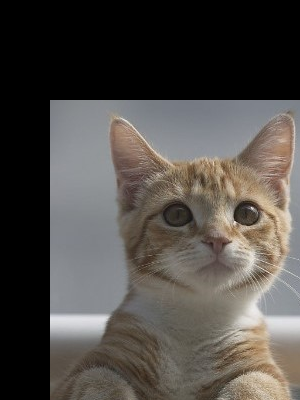

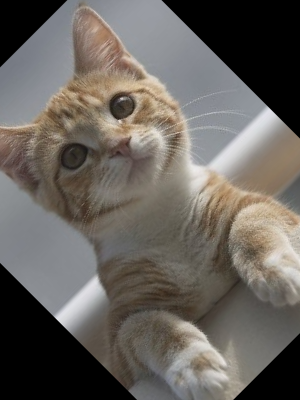

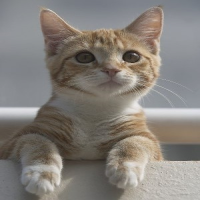

In [17]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/cat_300x400.jpg')

cv2_imshow(translate(image, 50, 100))
cv2_imshow(rotate(image, 45))
cv2_imshow(resize(image, 200, 200))

### 세 개의 점으로 어파인 변환 매트릭스 구하기

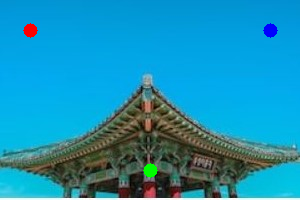

In [18]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

# 이미지에 점 세 개 표시
cv2.circle(image, (30,30), 7, (0,0,255), -1)
cv2.circle(image, (width//2,height-30), 7, (0,255,0), -1)
cv2.circle(image, (width-30,30), 7, (255,0,0), -1)

cv2_imshow(image)

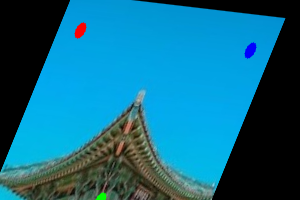

[[ 0.70833333 -0.46428571 72.67857143]
 [ 0.08333333  1.14285714 -6.78571429]]


In [20]:
# 변환점 세 점 위치와 변환 후 세 점 위치
pointBefore = np.float32([[30, 30], [width//2, height-30], [width-30, 30]])
pointAfter = np.float32([[80, 30], [100, 200], [250, 50]])

# 어파인 매트릭스 구하기
M = cv2.getAffineTransform(pointBefore, pointAfter)
imageResult = cv2.warpAffine(image, M, (width, height))

cv2_imshow(imageResult)
print(M)

## 이미지의 원근 변환
**원근 변환 (Perspective Transformation)**
- 어파인 보다 자유도가 높다
- 원근 변환은 직사각형 형태의 영상을 임의의 볼록 사각형 형태로 변경할 수 있음
- 변환 전 이미지와 변환 후 이미지의 네 점의 이동관계에 의해 결정
- **Perspective Transformation Matrix:** 어파인 변환은 두 이미지의 관계를 정의한 3x3매트릭스로 설명할 수 있다
- 매트릭스는 numpy.float32 실수형 자료형을 사용

**네 개의 점으로 원근변환 매트릭스 구하기**

```cv2.getPerspectiveTransform(pointBefor, pointAfter)```



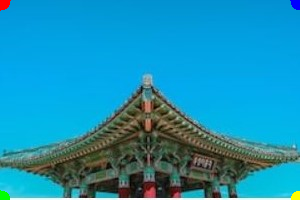

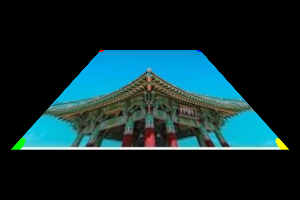

In [21]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

# 이미지에 점 4개 표시
cv2.circle(image, (0,0), 10, (0,0,255), -1)
cv2.circle(image, (0,height), 10, (0,255,0), -1)
cv2.circle(image, (width,0), 10, (255,0,0), -1)
cv2.circle(image, (width,height), 10, (0,255,255), -1)

# 변환 전 4점 위치와 변환후 4점의 위치
pointBefore = np.float32([[0,0], [0,height], [width, 0], [width,height]])
pointAfter = np.float32([[100,50], [10,height-50], [width-100, 50], [width-10,height-50]])

# 원근변환 행렬 구하기
M = cv2.getPerspectiveTransform(pointBefore, pointAfter)

# 원근 변환 적용
result = cv2.warpPerspective(image, M, (width, height))

cv2_imshow(image)
cv2_imshow(result)

**원근변환으로 ROI 정사각형 이미지 추출하기**

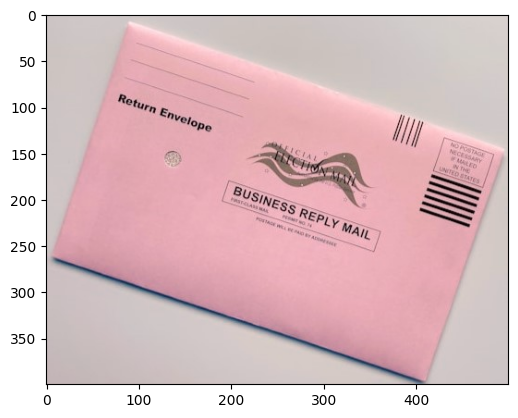

In [24]:

import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/envelope500x400.jpg')
(height, width, chennel) = image.shape[:]

imgplot = plt.imshow(image)
plt.show()

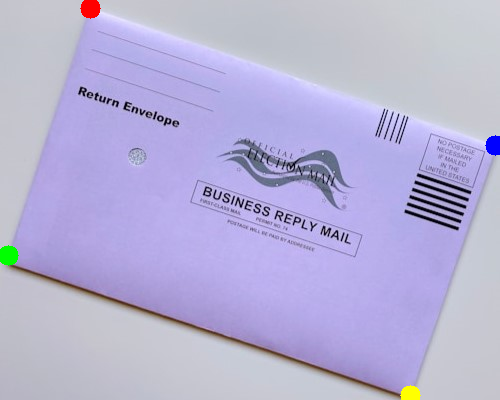

In [25]:
#네 점의 좌표를 정한다.
P1 = (90,8)
P2 = (8,255)
P3 = (410,395)
P4 = (495,145)

# 이미지에 점 네 개 표시
cv2.circle(image, P1, 10, (0,0,255), -1)
cv2.circle(image, P2, 10, (0,255,0), -1)
cv2.circle(image, P3, 10, (0,255,255), -1)
cv2.circle(image, P4, 10, (255,0,0), -1)

#원본 이미지 출력
cv2_imshow(image)

[P1와 P4] 427 , [P2와 P3] 425
[P1와 P2] 260 , [P4와 P3] 264
envelope_width: 427 envelope_height: 264




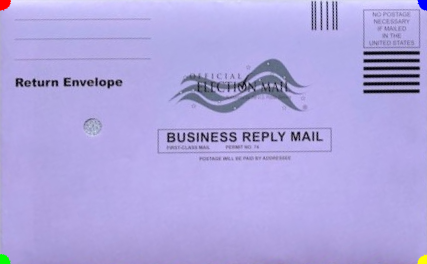

In [26]:
# 두 점 사이의 거리 구하기
def distance(point1, point2):
  x1,y1 = point1
  x2,y2 = point2
  # np.sqrt 제곱근, np.power 제곱 -> 절대값 구하기 -> 삼각형 빗변 구하는 공식
  result = np.sqrt(np.power(x1 - x2, 2) + np.power(y1 - y2,2))
  return result

#ROI의 가로,세로 길이 구하기
envelope_width = max(int(distance(P1,P4)),int(distance(P2,P3)))
envelope_height = max(int(distance(P1,P2)), int(distance(P4,P3)))

print("[P1와 P4]",int(distance(P1,P4)),", [P2와 P3]",int(distance(P2,P3)))
print("[P1와 P2]",int(distance(P1,P2)),", [P4와 P3]",int(distance(P4,P3)))
print("envelope_width:",envelope_width,"envelope_height:",envelope_height)
print("\n")

#변환 전 네 점 위치와 변환 후 네 점 위치
pointsBefore = np.float32([P1, P2, P3, P4])
pointsAfter = np.float32([[0,0], [0,envelope_height], [envelope_width,envelope_height], [envelope_width,0]])


#원근변환 행렬 구하고 원근변환 적용
M = cv2.getPerspectiveTransform(pointsBefore,pointsAfter)
result = cv2.warpPerspective(image, M, (envelope_width, envelope_height))


#결과 이미지 출력
cv2_imshow(result)

## 이미지의 리매핑 (Remapping)
- 리매핑은 이미지의 픽셀들을 다른 위치에 재배치하는 변환
  - remap()함수를 사용해 결과 이미지의 좌표를 원본 이미지의 어느 좌표를 참조해서가져올지 설정후
  - 결과 이미지의 모든 픽셀값을 셋팅해 결과 이미지를 출력
- 이미지를 직선이 아닌, 자유도 높은 곡선으로 표현가능
- 어파인 변환, 투시변환 등, 다양한 변환을 리매핑으로 표현 가능

        cv2.remap(srcImage, mapx, mapy, interpolation)

parameter:
-srcImage: 입력 이미지
- mapx, mapy: 결과 이미지의 (x, y) 좌표가 참조할 원본 이미지의 x좌표와 y좌표
   - 자료형이 np.float32인 numpy.ndarray
- interpolation: 보간법

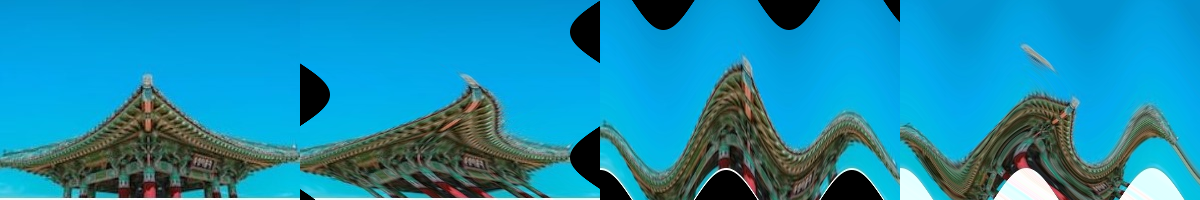

In [27]:
image = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Image_processing/photos/building300x200.JPG')
(height, width, chennel) = image.shape[:]

waveLength = 20  # 파장
amplitude = 30  # 진폭

# np.indice는 행렬의 인덱스값의 x좌표값과 y좌표값을 각각 행렬의 형태로 변환
mapy, mapx = np.indices((height, width), dtype = np.float32)
# sin을 대입한 mapx와 cos를 대입한 mapy
sinx = mapx + amplitude * np.sin(mapy/waveLength)
cosy = mapy + amplitude * np.cos(mapx/waveLength)

# remap을 적용한 이미지
sinximage = cv2.remap(image, sinx, mapy, cv2.INTER_LINEAR) # x축만 sin곡선 적용
cosyimage = cv2.remap(image, mapx, cosy, cv2.INTER_LINEAR) # y축만 cos곡선 적용
bothimage = cv2.remap(image, sinx, cosy, cv2.INTER_LINEAR, None, cv2.BORDER_REPLICATE)

remap_frame = cv2.hconcat([image, sinximage, cosyimage, bothimage])
cv2_imshow(remap_frame)